# 18 — Demand Forecasting for Dynamic Pricing

Forecast **demand theo tháng** (booking stays / room-nights) để hỗ trợ dynamic pricing trên `hotel_bookings_v5.csv`.

## Mục tiêu

1. Xây chuỗi thời gian demand tháng (overall + theo `hotel`)
2. So sánh **Seasonal Naive · Rolling Average · Holt–Winters (ETS) · SARIMA**
3. Walk-forward backtest → chọn model tốt nhất
4. Forecast horizon ngắn + **hàm ý pricing** (liên kết notebook 17)

## Phạm vi

- Demand thực hiện: `is_canceled = 0`
- Primary target: **monthly booking count**
- Secondary: **room-nights** (`total_nights`)
- Chuỗi: 2015-07 → 2017-08 (~26 tháng) — seasonality mạnh, mẫu ngắn → ưu tiên model ổn định

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "18"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
SEASON = 12
MIN_TRAIN = 14  # need >= 1 full seasonal cycle + buffer
HOLDOUT_MONTHS = 6

print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")

ROOT: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\18


In [2]:
def fmt_int(n) -> str:
    return f"{int(round(n)):,}".replace(",", ".")


def fmt_pct(x: float, d: int = 1) -> str:
    return f"{x * 100:.{d}f}%".replace(".", ",")


def savefig(name: str) -> Path:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((np.asarray(y_true, float) - np.asarray(y_pred, float)) ** 2)))


def load_monthly_demand() -> tuple[pd.DataFrame, pd.DataFrame]:
    df = pd.read_csv(DATA_PATH)
    stay = df[df["is_canceled"] == 0].copy()
    stay["month_num"] = stay["arrival_date_month"].map(MONTH_MAP)
    stay["ym"] = pd.to_datetime(
        dict(year=stay["arrival_date_year"], month=stay["month_num"], day=1)
    )
    if "total_nights" not in stay.columns:
        stay["total_nights"] = (
            stay["stays_in_weekend_nights"] + stay["stays_in_week_nights"]
        ).clip(lower=0)

    overall = (
        stay.groupby("ym", as_index=False)
        .agg(bookings=("hotel", "size"), room_nights=("total_nights", "sum"))
        .sort_values("ym")
        .reset_index(drop=True)
    )
    by_hotel = (
        stay.groupby(["hotel", "ym"], as_index=False)
        .agg(bookings=("hotel", "size"), room_nights=("total_nights", "sum"))
        .sort_values(["hotel", "ym"])
        .reset_index(drop=True)
    )
    return overall, by_hotel


overall, by_hotel = load_monthly_demand()
print(f"Months: {len(overall)} | {overall['ym'].min().date()} → {overall['ym'].max().date()}")
print(f"Total stay bookings: {fmt_int(overall['bookings'].sum())}")
print(f"Total room-nights: {fmt_int(overall['room_nights'].sum())}")
display(overall.head(8))

Months: 26 | 2015-07-01 → 2017-08-01
Total stay bookings: 59.527
Total room-nights: 210.586


,ym,bookings,room_nights
0,2015-07-01,1095,5367
1,2015-08-01,1755,7631
2,2015-09-01,2027,8373
3,2015-10-01,2008,6764
4,2015-11-01,1272,4134
5,2015-12-01,1507,4435
6,2016-01-01,1439,3694
7,2016-02-01,2152,6150


## 1. EDA — chuỗi demand tháng

Saved: reports\figures\18\01_monthly_demand_overall.png


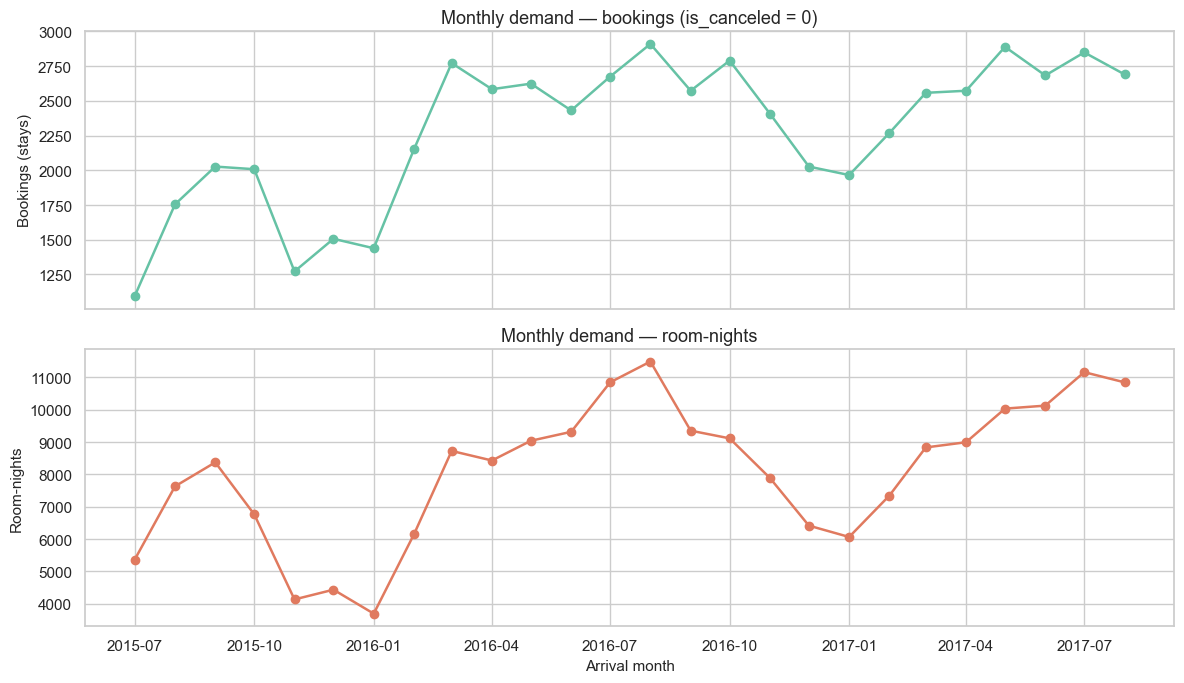

Saved: reports\figures\18\02_monthly_demand_by_hotel.png


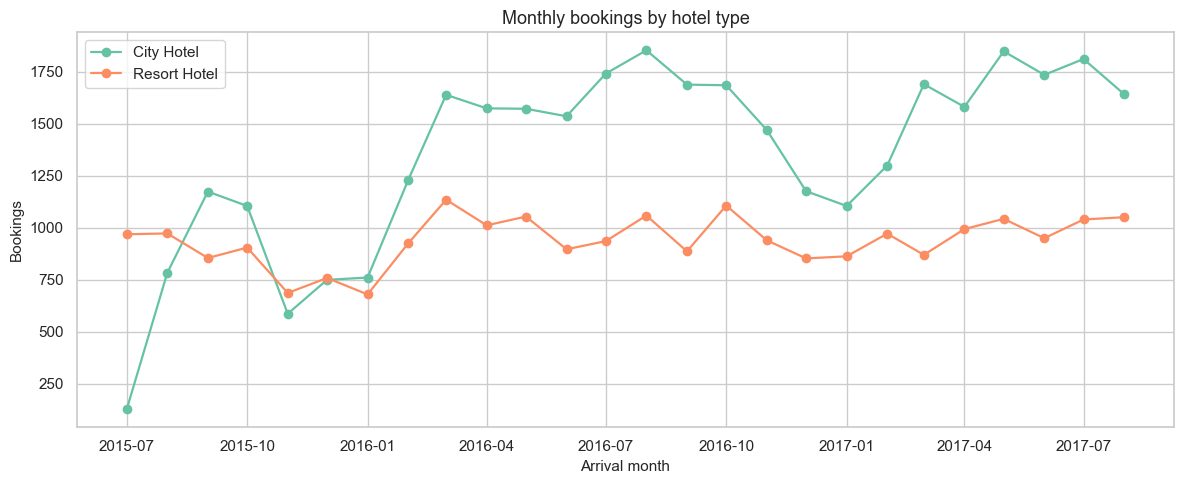

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(overall["ym"], overall["bookings"], marker="o", lw=1.8)
axes[0].set_ylabel("Bookings (stays)")
axes[0].set_title("Monthly demand — bookings (is_canceled = 0)")

axes[1].plot(overall["ym"], overall["room_nights"], marker="o", color="#e07a5f", lw=1.8)
axes[1].set_ylabel("Room-nights")
axes[1].set_title("Monthly demand — room-nights")
axes[1].set_xlabel("Arrival month")

savefig("01_monthly_demand_overall.png")
plt.show()

# By hotel
fig, ax = plt.subplots(figsize=(12, 5))
for hotel, g in by_hotel.groupby("hotel"):
    ax.plot(g["ym"], g["bookings"], marker="o", label=hotel, lw=1.6)
ax.set_title("Monthly bookings by hotel type")
ax.set_ylabel("Bookings")
ax.set_xlabel("Arrival month")
ax.legend()
savefig("02_monthly_demand_by_hotel.png")
plt.show()

Saved: reports\figures\18\03_seasonal_index_bookings.png


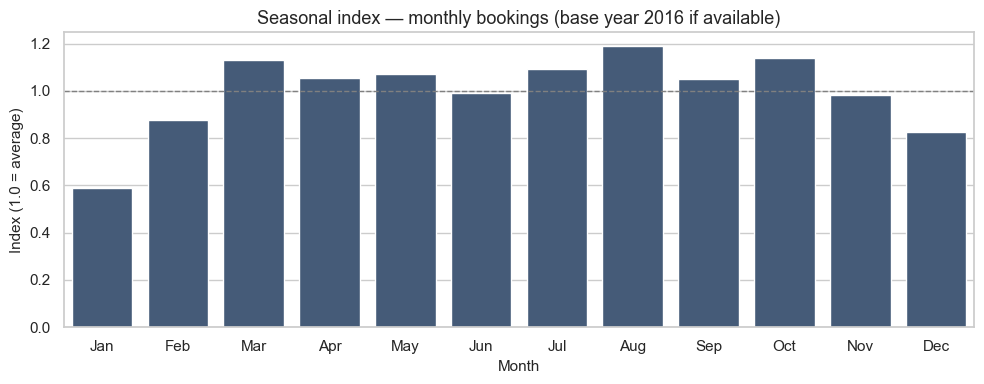

,month,season_index,month_name
0,1,0.588,Jan
1,2,0.879,Feb
2,3,1.132,Mar
3,4,1.055,Apr
4,5,1.072,May
5,6,0.993,Jun
6,7,1.092,Jul
7,8,1.188,Aug
8,9,1.051,Sep
9,10,1.139,Oct


In [4]:
# Seasonal index (bookings): mean month / grand mean — dùng 2016 full year làm neo nếu có
overall["month"] = overall["ym"].dt.month
overall["year"] = overall["ym"].dt.year

full_2016 = overall[overall["year"] == 2016]
if len(full_2016) == 12:
    base = full_2016
else:
    base = overall

month_mean = base.groupby("month")["bookings"].mean()
season_index = (month_mean / month_mean.mean()).rename("season_index")
season_df = season_index.reset_index()
season_df["month_name"] = pd.to_datetime(season_df["month"], format="%m").dt.strftime("%b")

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=season_df, x="month_name", y="season_index", ax=ax, color="#3d5a80")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_title("Seasonal index — monthly bookings (base year 2016 if available)")
ax.set_ylabel("Index (1.0 = average)")
ax.set_xlabel("Month")
savefig("03_seasonal_index_bookings.png")
plt.show()

display(season_df.round(3))

## 2. Models

| Model | Vai trò |
|---|---|
| Seasonal Naive | Baseline mạnh: `ŷ_t = y_{t-12}` |
| Rolling Average (w=3) | Baseline mượt — thường kém ở peak |
| Holt–Winters (ETS) | Primary candidate — trend + seasonality 12 |
| SARIMA | Đối chứng classical — `(p,d,q)(P,D,Q)₁₂` |

Walk-forward **1-step ahead**: train tối thiểu 14 tháng, đánh giá trên các tháng còn lại (và báo cáo riêng holdout 6 tháng cuối).

In [5]:
def seasonal_naive_forecast(history: pd.Series, steps: int = 1) -> np.ndarray:
    hist = history.astype(float)
    out = []
    cur = hist.copy()
    for _ in range(steps):
        if len(cur) >= SEASON:
            pred = float(cur.iloc[-SEASON])
        else:
            pred = float(cur.mean())
        out.append(pred)
        cur = pd.concat([cur, pd.Series([pred])], ignore_index=True)
    return np.asarray(out)


def rolling_avg_forecast(history: pd.Series, window: int = 3, steps: int = 1) -> np.ndarray:
    cur = history.astype(float).copy()
    out = []
    for _ in range(steps):
        pred = float(cur.iloc[-window:].mean())
        out.append(pred)
        cur = pd.concat([cur, pd.Series([pred])], ignore_index=True)
    return np.asarray(out)


def ets_forecast(history: pd.Series, steps: int = 1) -> np.ndarray:
    y = history.astype(float)
    # additive seasonality ổn định hơn trên mẫu ngắn; fallback nếu fit fail
    try:
        model = ExponentialSmoothing(
            y,
            trend="add",
            seasonal="add",
            seasonal_periods=SEASON,
            initialization_method="estimated",
        ).fit(optimized=True)
        return np.asarray(model.forecast(steps), dtype=float)
    except Exception:
        model = ExponentialSmoothing(
            y, trend="add", seasonal=None, initialization_method="estimated"
        ).fit(optimized=True)
        return np.asarray(model.forecast(steps), dtype=float)


def sarima_forecast(history: pd.Series, steps: int = 1) -> np.ndarray:
    y = history.astype(float)
    # Small grid — ưu tiên order đơn giản cho chuỗi ~26 điểm
    candidates = [
        ((1, 0, 0), (0, 1, 1, SEASON)),
        ((0, 1, 1), (0, 1, 1, SEASON)),
        ((1, 1, 0), (0, 1, 1, SEASON)),
        ((1, 1, 1), (0, 1, 0, SEASON)),
        ((0, 1, 1), (1, 1, 0, SEASON)),
    ]
    best_aic = np.inf
    best_res = None
    for order, seasonal_order in candidates:
        try:
            res = SARIMAX(
                y,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_res = res
        except Exception:
            continue
    if best_res is None:
        # last resort non-seasonal
        best_res = SARIMAX(y, order=(1, 1, 1)).fit(disp=False)
    return np.asarray(best_res.forecast(steps), dtype=float)


FORECASTERS = {
    "seasonal_naive": lambda h, s=1: seasonal_naive_forecast(h, s),
    "rolling_avg_3": lambda h, s=1: rolling_avg_forecast(h, 3, s),
    "holt_winters": lambda h, s=1: ets_forecast(h, s),
    "sarima": lambda h, s=1: sarima_forecast(h, s),
}
print("Forecasters ready:", list(FORECASTERS))

Forecasters ready: ['seasonal_naive', 'rolling_avg_3', 'holt_winters', 'sarima']


## 3. Walk-forward backtest (1-step)

In [6]:
def walk_forward(y: pd.Series, min_train: int = MIN_TRAIN) -> pd.DataFrame:
    rows = []
    y = y.astype(float).reset_index(drop=True)
    for t in range(min_train, len(y)):
        history = y.iloc[:t]
        actual = float(y.iloc[t])
        for name, fn in FORECASTERS.items():
            try:
                pred = float(fn(history, 1)[0])
            except Exception as e:
                pred = np.nan
                err = str(e)
            else:
                err = ""
            rows.append(
                {
                    "t": t,
                    "model": name,
                    "actual": actual,
                    "pred": pred,
                    "abs_err": abs(actual - pred) if pd.notna(pred) else np.nan,
                    "error": err,
                }
            )
    return pd.DataFrame(rows)


y_bookings = overall.set_index("ym")["bookings"]
wf = walk_forward(y_bookings)
metrics = (
    wf.dropna(subset=["pred"])
    .groupby("model")
    .apply(
        lambda g: pd.Series(
            {
                "n": len(g),
                "MAE": mae(g["actual"], g["pred"]),
                "RMSE": rmse(g["actual"], g["pred"]),
                "MAPE": mape(g["actual"], g["pred"]),
            }
        ),
        include_groups=False,
    )
    .sort_values("MAPE")
)
print("Walk-forward metrics (all origin months after min_train):")
display(metrics.style.format({"MAE": "{:.1f}", "RMSE": "{:.1f}", "MAPE": "{:.2%}"}))

# Holdout = last HOLDOUT_MONTHS of series
holdout_start_t = len(y_bookings) - HOLDOUT_MONTHS
wf_hold = wf[wf["t"] >= holdout_start_t]
metrics_hold = (
    wf_hold.dropna(subset=["pred"])
    .groupby("model")
    .apply(
        lambda g: pd.Series(
            {
                "n": len(g),
                "MAE": mae(g["actual"], g["pred"]),
                "RMSE": rmse(g["actual"], g["pred"]),
                "MAPE": mape(g["actual"], g["pred"]),
            }
        ),
        include_groups=False,
    )
    .sort_values("MAPE")
)
print(f"\nHoldout last {HOLDOUT_MONTHS} months:")
display(metrics_hold.style.format({"MAE": "{:.1f}", "RMSE": "{:.1f}", "MAPE": "{:.2%}"}))

best_model = metrics_hold["MAPE"].idxmin()
print(f"\nBest model on holdout (MAPE): {best_model}")

Walk-forward metrics (all origin months after min_train):


,n,MAE,RMSE,MAPE
model,,,,
rolling_avg_3,12.000000,260.1,315.6,10.96%
sarima,12.000000,277.5,325.8,11.28%
holt_winters,12.000000,295.4,347.8,11.99%
seasonal_naive,12.000000,396.9,501.7,16.30%



Holdout last 6 months:


,n,MAE,RMSE,MAPE
model,,,,
seasonal_naive,6.000000,189.2,207.3,6.93%
sarima,6.000000,187.1,225.1,6.97%
rolling_avg_3,6.000000,243.6,296.3,9.06%
holt_winters,6.000000,250.5,308.7,9.27%



Best model on holdout (MAPE): seasonal_naive


Saved: reports\figures\18\04_walkforward_forecasts.png


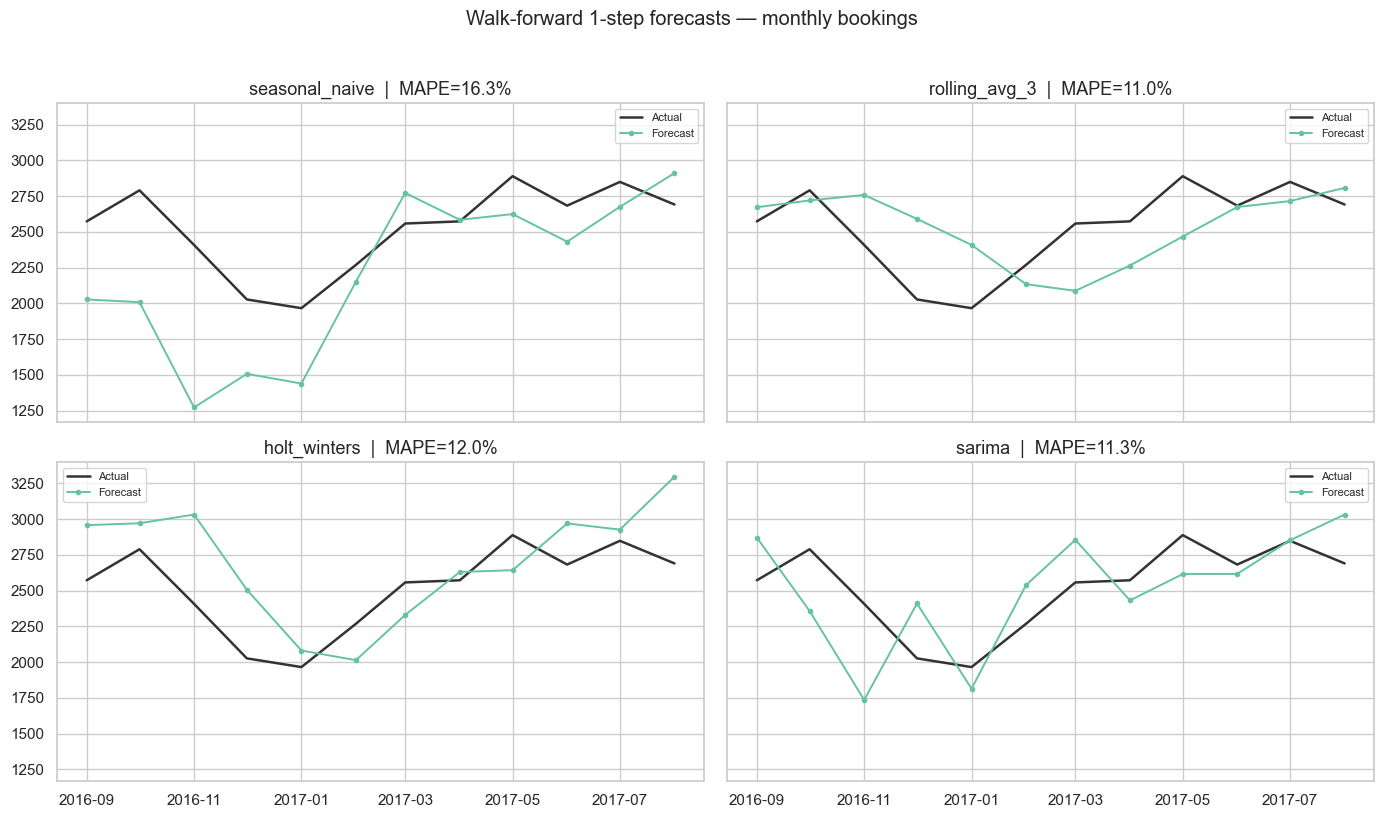

In [7]:
# Actual vs predicted on walk-forward for each model
dates = overall["ym"].iloc[MIN_TRAIN:].reset_index(drop=True)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, model in zip(axes, FORECASTERS.keys()):
    g = wf[wf["model"] == model].sort_values("t")
    ax.plot(dates, g["actual"].values, label="Actual", color="#333", lw=1.8)
    ax.plot(dates, g["pred"].values, label="Forecast", marker="o", ms=3, lw=1.4)
    m = metrics.loc[model, "MAPE"] if model in metrics.index else np.nan
    ax.set_title(f"{model}  |  MAPE={m:.1%}" if pd.notna(m) else model)
    ax.legend(fontsize=8)

fig.suptitle("Walk-forward 1-step forecasts — monthly bookings", y=1.02)
savefig("04_walkforward_forecasts.png")
plt.show()

Saved: reports\figures\18\05_holdout_metrics.png


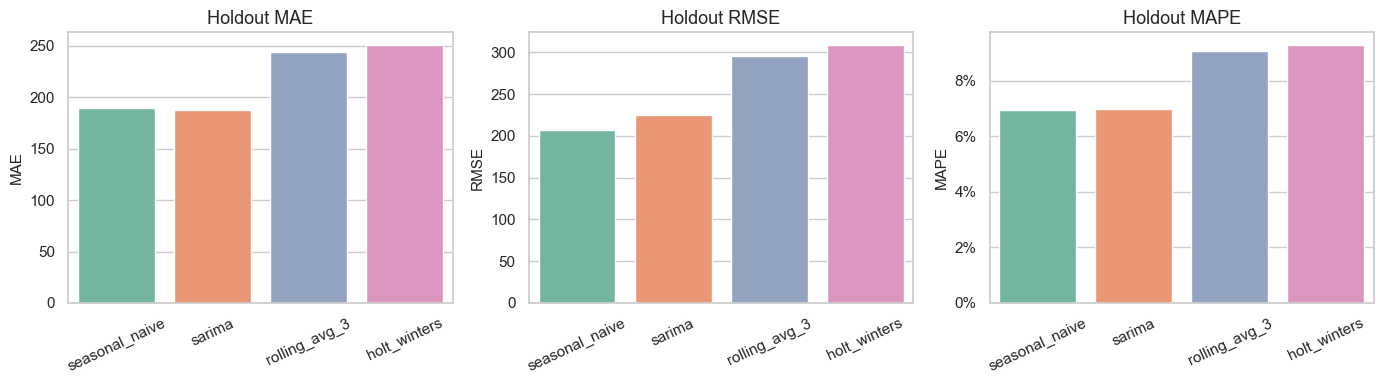

Saved metrics CSVs


In [8]:
# Metric comparison bar chart
plot_m = metrics_hold.reset_index().melt(
    id_vars="model", value_vars=["MAE", "RMSE", "MAPE"], var_name="metric", value_name="value"
)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    sub = metrics_hold.reset_index()
    sns.barplot(data=sub, x="model", y=metric, ax=ax, hue="model", legend=False)
    ax.set_title(f"Holdout {metric}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    if metric == "MAPE":
        ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
savefig("05_holdout_metrics.png")
plt.show()

metrics.to_csv(FIG_DIR / "walkforward_metrics_all.csv")
metrics_hold.to_csv(FIG_DIR / "holdout_metrics.csv")
print("Saved metrics CSVs")

## 4. Backtest theo hotel type

Holdout MAPE by hotel × model:


hotel,City Hotel,Resort Hotel
model,,
holt_winters,15.65%,5.26%
rolling_avg_3,12.80%,5.29%
sarima,6.11%,11.28%
seasonal_naive,7.77%,8.29%


Saved: reports\figures\18\06_holdout_mape_by_hotel.png


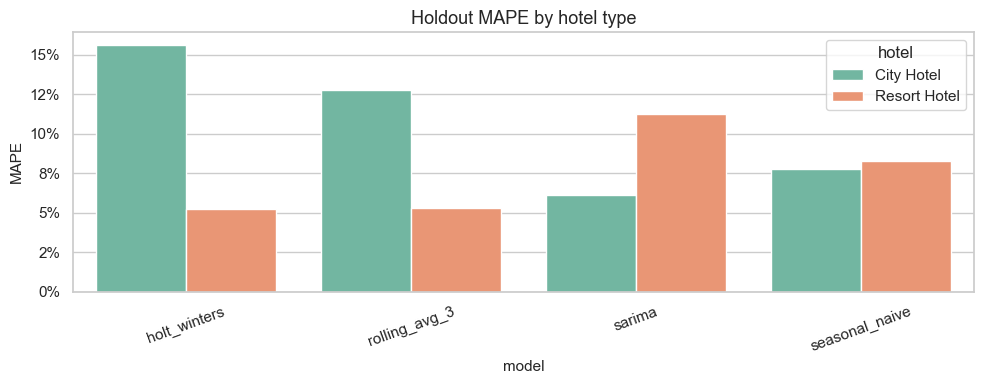

In [9]:
hotel_rows = []
for hotel, g in by_hotel.groupby("hotel"):
    y = g.set_index("ym")["bookings"].asfreq("MS")
    # fill any accidental gaps (shouldn't exist)
    y = y.interpolate(limit_direction="both")
    wf_h = walk_forward(y)
    hold_start = len(y) - HOLDOUT_MONTHS
    m = (
        wf_h[wf_h["t"] >= hold_start]
        .dropna(subset=["pred"])
        .groupby("model")
        .apply(
            lambda x: pd.Series(
                {
                    "MAE": mae(x["actual"], x["pred"]),
                    "MAPE": mape(x["actual"], x["pred"]),
                }
            ),
            include_groups=False,
        )
    )
    m["hotel"] = hotel
    hotel_rows.append(m.reset_index())

hotel_metrics = pd.concat(hotel_rows, ignore_index=True)
print("Holdout MAPE by hotel × model:")
pivot = hotel_metrics.pivot(index="model", columns="hotel", values="MAPE")
display(pivot.style.format("{:.2%}"))
hotel_metrics.to_csv(FIG_DIR / "holdout_metrics_by_hotel.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
plot_h = hotel_metrics.copy()
sns.barplot(data=plot_h, x="model", y="MAPE", hue="hotel", ax=ax)
ax.set_title("Holdout MAPE by hotel type")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.tick_params(axis="x", rotation=20)
savefig("06_holdout_mape_by_hotel.png")
plt.show()

## 5. Fit final model + forecast horizon

In [10]:
HORIZON = 6  # months ahead from last observed month
y = y_bookings.astype(float)

# Refit best model on full history
if best_model == "seasonal_naive":
    fc_values = seasonal_naive_forecast(y, HORIZON)
elif best_model == "rolling_avg_3":
    fc_values = rolling_avg_forecast(y, 3, HORIZON)
elif best_model == "holt_winters":
    fc_values = ets_forecast(y, HORIZON)
else:
    fc_values = sarima_forecast(y, HORIZON)

# Also produce ETS + Seasonal Naive for overlay regardless of winner
fc_ets = ets_forecast(y, HORIZON)
fc_naive = seasonal_naive_forecast(y, HORIZON)
fc_sarima = sarima_forecast(y, HORIZON)

last = y.index.max()
fc_index = pd.date_range(last + pd.offsets.MonthBegin(1), periods=HORIZON, freq="MS")
forecast_df = pd.DataFrame(
    {
        "ym": fc_index,
        "best_model": best_model,
        "forecast_best": fc_values,
        "forecast_holt_winters": fc_ets,
        "forecast_seasonal_naive": fc_naive,
        "forecast_sarima": fc_sarima,
    }
)
# Clip negative forecasts (demand can't be negative)
for c in forecast_df.columns:
    if c.startswith("forecast_"):
        forecast_df[c] = forecast_df[c].clip(lower=0)

display(forecast_df.round(0))
forecast_df.to_csv(FIG_DIR / "forecast_next_6m.csv", index=False)
print(f"Saved: {(FIG_DIR / 'forecast_next_6m.csv').relative_to(ROOT)}")

,ym,best_model,forecast_best,forecast_holt_winters,forecast_seasonal_naive,forecast_sarima
0,2017-09-01,seasonal_naive,2573.0,2659.0,2573.0,1791.0
1,2017-10-01,seasonal_naive,2790.0,2758.0,2790.0,2226.0
2,2017-11-01,seasonal_naive,2408.0,2198.0,2408.0,2171.0
3,2017-12-01,seasonal_naive,2027.0,2125.0,2027.0,1221.0
4,2018-01-01,seasonal_naive,1966.0,2061.0,1966.0,1166.0
5,2018-02-01,seasonal_naive,2269.0,2569.0,2269.0,1090.0


Saved: reports\figures\18\forecast_next_6m.csv


Saved: reports\figures\18\07_forecast_horizon.png


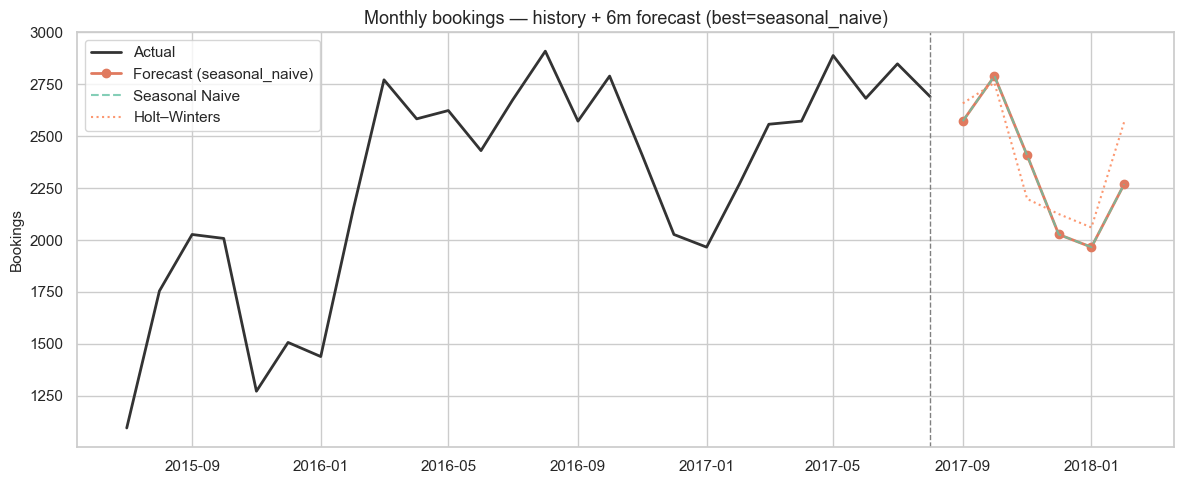

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y.index, y.values, label="Actual", color="#333", lw=2)
ax.plot(
    forecast_df["ym"],
    forecast_df["forecast_best"],
    label=f"Forecast ({best_model})",
    marker="o",
    lw=2,
    color="#e07a5f",
)
ax.plot(
    forecast_df["ym"],
    forecast_df["forecast_seasonal_naive"],
    label="Seasonal Naive",
    ls="--",
    alpha=0.8,
)
ax.plot(
    forecast_df["ym"],
    forecast_df["forecast_holt_winters"],
    label="Holt–Winters",
    ls=":",
    alpha=0.9,
)
ax.axvline(y.index.max(), color="gray", ls="--", lw=1)
ax.set_title(f"Monthly bookings — history + {HORIZON}m forecast (best={best_model})")
ax.set_ylabel("Bookings")
ax.legend()
savefig("07_forecast_horizon.png")
plt.show()

## 6. Dynamic pricing implications

Ghép forecast demand với **season index** để đề xuất stance pricing theo tháng forecast:
- Demand cao + season index cao → bảo vệ rate / hạn chế discount
- Demand thấp + season index thấp → promo / early-bird

,ym,forecast_best,season_index,demand_index,combined_pressure,pricing_stance
0,2017-09-01,2573.0,1.051,1.051,1.051,"NEUTRAL — hold BAR, tactical weekend premium"
1,2017-10-01,2790.0,1.139,1.139,1.139,"NEUTRAL — hold BAR, tactical weekend premium"
2,2017-11-01,2408.0,0.983,0.983,0.983,"NEUTRAL — hold BAR, tactical weekend premium"
3,2017-12-01,2027.0,0.828,0.828,0.828,STIMULATE — promo / early-bird / package
4,2018-01-01,1966.0,0.588,0.803,0.695,STIMULATE — promo / early-bird / package
5,2018-02-01,2269.0,0.879,0.927,0.903,"NEUTRAL — hold BAR, tactical weekend premium"


Saved: reports\figures\18\08_pricing_stance.png


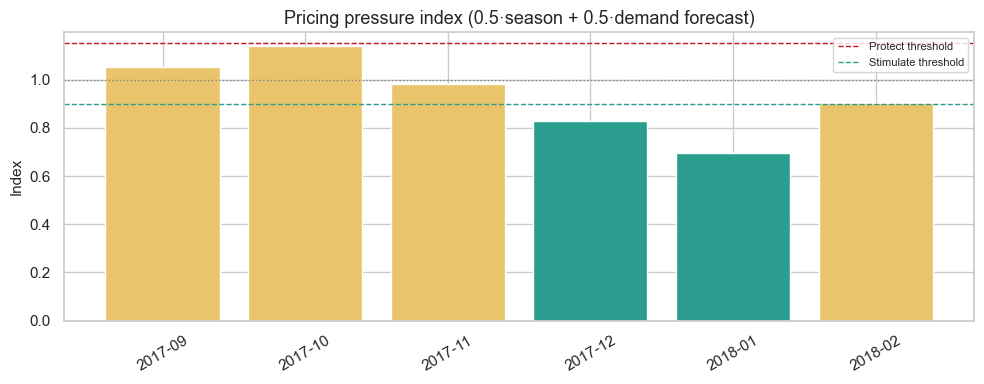

In [12]:
# Demand stance relative to historical monthly mean (2016 base if available)
hist_month_mean = base.groupby(base["ym"].dt.month)["bookings"].mean()
grand = float(hist_month_mean.mean())

pricing = forecast_df.copy()
pricing["month"] = pricing["ym"].dt.month
pricing["season_index"] = pricing["month"].map(season_index)
pricing["demand_index"] = pricing["forecast_best"] / grand
pricing["combined_pressure"] = 0.5 * pricing["season_index"] + 0.5 * pricing["demand_index"]


def stance(row) -> str:
    if row["combined_pressure"] >= 1.15:
        return "PROTECT — raise / harden BAR, limit promo"
    if row["combined_pressure"] <= 0.90:
        return "STIMULATE — promo / early-bird / package"
    return "NEUTRAL — hold BAR, tactical weekend premium"


pricing["pricing_stance"] = pricing.apply(stance, axis=1)
cols = [
    "ym",
    "forecast_best",
    "season_index",
    "demand_index",
    "combined_pressure",
    "pricing_stance",
]
display(pricing[cols].round(3))
pricing[cols].to_csv(FIG_DIR / "pricing_stance_forecast.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = pricing["pricing_stance"].map(
    {
        "PROTECT — raise / harden BAR, limit promo": "#c1121f",
        "STIMULATE — promo / early-bird / package": "#2a9d8f",
        "NEUTRAL — hold BAR, tactical weekend premium": "#e9c46a",
    }
)
ax.bar(pricing["ym"].dt.strftime("%Y-%m"), pricing["combined_pressure"], color=colors)
ax.axhline(1.15, color="#c1121f", ls="--", lw=1, label="Protect threshold")
ax.axhline(0.90, color="#2a9d8f", ls="--", lw=1, label="Stimulate threshold")
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.set_title("Pricing pressure index (0.5·season + 0.5·demand forecast)")
ax.set_ylabel("Index")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8)
savefig("08_pricing_stance.png")
plt.show()

## 7. Room-nights check (secondary target)

In [13]:
y_rn = overall.set_index("ym")["room_nights"].astype(float)
wf_rn = walk_forward(y_rn)
hold_start = len(y_rn) - HOLDOUT_MONTHS
metrics_rn = (
    wf_rn[wf_rn["t"] >= hold_start]
    .dropna(subset=["pred"])
    .groupby("model")
    .apply(
        lambda g: pd.Series(
            {"MAE": mae(g["actual"], g["pred"]), "MAPE": mape(g["actual"], g["pred"])}
        ),
        include_groups=False,
    )
    .sort_values("MAPE")
)
print("Holdout metrics — room-nights:")
display(metrics_rn.style.format({"MAE": "{:.1f}", "MAPE": "{:.2%}"}))
best_rn = metrics_rn["MAPE"].idxmin()
metrics_rn.to_csv(FIG_DIR / "holdout_metrics_room_nights.csv")
print(f"Best room-nights model (holdout MAPE): {best_rn}")

Holdout metrics — room-nights:


,MAE,MAPE
model,,
sarima,506.7,5.16%
seasonal_naive,572.2,5.69%
holt_winters,817.8,8.12%
rolling_avg_3,1356.2,14.01%


Best room-nights model (holdout MAPE): sarima
